Load and process results pth files

In [2]:
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [20]:
A = torch.load("../../results/bootstrap_results_A.pth", weights_only=False)
B = torch.load("../../results/bootstrap_results_B.pth", weights_only=False)
C = torch.load("../../results/bootstrap_results_C.pth", weights_only=False)
D = torch.load("../../results/bootstrap_results_D.pth", weights_only=False)

pulses = [
    "Static HPPC",
    "Dynamic PsRP 1 C/2",
]

targets = [
    "C/3 discharge capacity",
    "soc",
]

data = [
    A, B, C, D
]

In [47]:

def plot_true_vs_pred_axis(ax, pulse, target, result_dict, color='blue', n_splits=50, title=''):
    df = result_dict[f"{target}, {pulse}"]
    average_pred = df[list(range(n_splits))].mean(axis=1)
    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color,
        ax=ax)
    ax.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')
    ax.set_title(title)
    ax.annotate("r^2: {:.3f}".format(r2_score(df[target], average_pred)), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)



def plot_true_vs_pred(pulse, target, result_dict, color='blue', n_splits=50):
    fig = plt.figure()
    df = result_dict[f"{target}, {pulse}"]
    
    average_pred = df[list(range(n_splits))].mean(axis=1)

    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color)
        # s=2)
    plt.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')

    plt.title(f"Predicting {target} from {pulse}", size='xx-large')
    plt.xlabel("Actual", size='xx-large')
    plt.ylabel("Predicted", size='xx-large')
    plt.show()
    
    if target.endswith("threshold"):
        print(classification_report(df[target], average_pred.round()))
        
    else:
        print('r2 score: ', r2_score(df[target], average_pred))
        print('mae score: ', mean_absolute_error(df[target], average_pred))
        print('max error: ', max_error(df[target], average_pred))

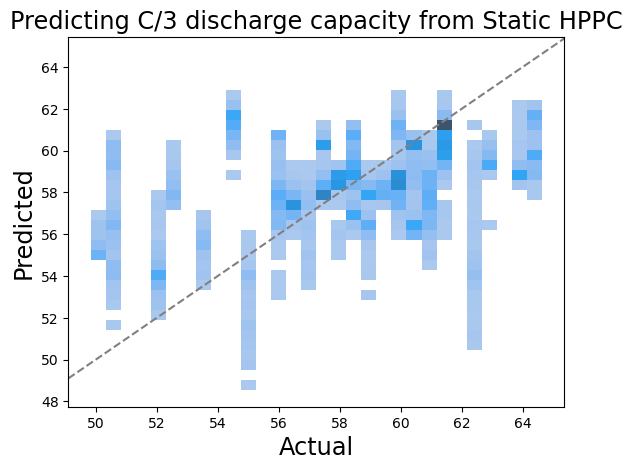

r2 score:  0.16160277567888393
mae score:  2.571968144457418
max error:  11.576884460449222


In [43]:
plot_true_vs_pred('Static HPPC', 'C/3 discharge capacity', A, color='tab:blue')

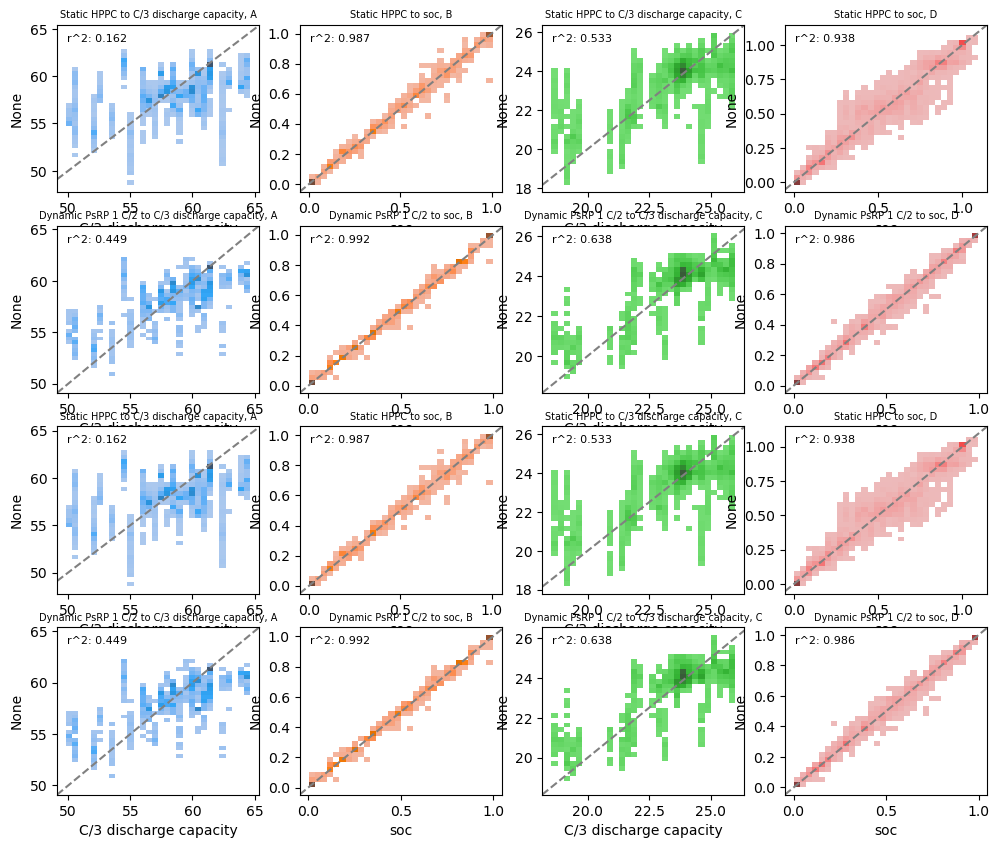

In [48]:
fig, ax = plt.subplots(4, 4, figsize=(12, 10))
ax = ax.ravel()

for i in range(4):
    for j in range(4):
        plot_true_vs_pred_axis(ax[i*4 + j], pulses[i%2], targets[j%2], data[j], color=sns.color_palette("tab10")[j]) 
        ax[i*4 + j].set_title(f"{pulses[i%2]} to {targets[j%2]}, {chr(65+j)}", fontsize=7, pad=5)

# for i in range(4):
    # ax[i].set_xlabel("Actual", fontsize=5)
    # ax[i].set_ylabel("Predicted", fontsize=5)